In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        (os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -q transformers librosa torchmetrics audiomentations wandb lightgbm catboost xgboost scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 12.3 MB/s eta 0:00:00


In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display
import wandb
import torch
import warnings
warnings.filterwarnings("ignore")

# reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)
print("all library done")

all library done


In [4]:
# login with API key directly
import wandb

wandb.login(key="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")
print("W&B logged in successfully")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 23f3000162 (23f3000162-iit-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B logged in successfully


In [5]:
BASE_PATH   = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
GENRES_PATH = os.path.join(BASE_PATH, "genres_stems")
ESC_PATH    = os.path.join(BASE_PATH, "ESC-50-master", "audio")
ESC_META    = os.path.join(BASE_PATH, "ESC-50-master", "meta", "esc50.csv")
MASHUPS_DIR = os.path.join(BASE_PATH, "mashups")

GENRES = ["blues","classical","country","disco","hiphop",
          "jazz","metal","pop","reggae","rock"]

SAMPLE_RATE    = 16000
REQUIRED_STEMS = ["drums.wav","vocals.wav","bass.wav","other.wav"]

print("Paths configured!")
print(f"Base path exists: {os.path.exists(BASE_PATH)}")

Paths configured!
Base path exists: True


In [6]:
def build_song_index():
    index = {}
    for genre in GENRES:
        genre_path = os.path.join(GENRES_PATH, genre)
        valid = []
        for folder in sorted(os.listdir(genre_path)):
            folder_path = os.path.join(genre_path, folder)
            if not os.path.isdir(folder_path):
                continue
            if all(os.path.exists(os.path.join(folder_path, s)) for s in REQUIRED_STEMS):
                valid.append(folder_path)
        index[genre] = valid
    return index

song_index = build_song_index()
print("Song index built!")
for genre in GENRES:
    print(f"  {genre}: {len(song_index[genre])} songs")

Song index built!
  blues: 100 songs
  classical: 100 songs
  country: 100 songs
  disco: 100 songs
  hiphop: 100 songs
  jazz: 100 songs
  metal: 100 songs
  pop: 100 songs
  reggae: 100 songs
  rock: 100 songs


wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260228_232749-r0iv7xro
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run milestone1-eda
wandb: ⭐️ View project at https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026
wandb: 🚀 View run at https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026/runs/r0iv7xro


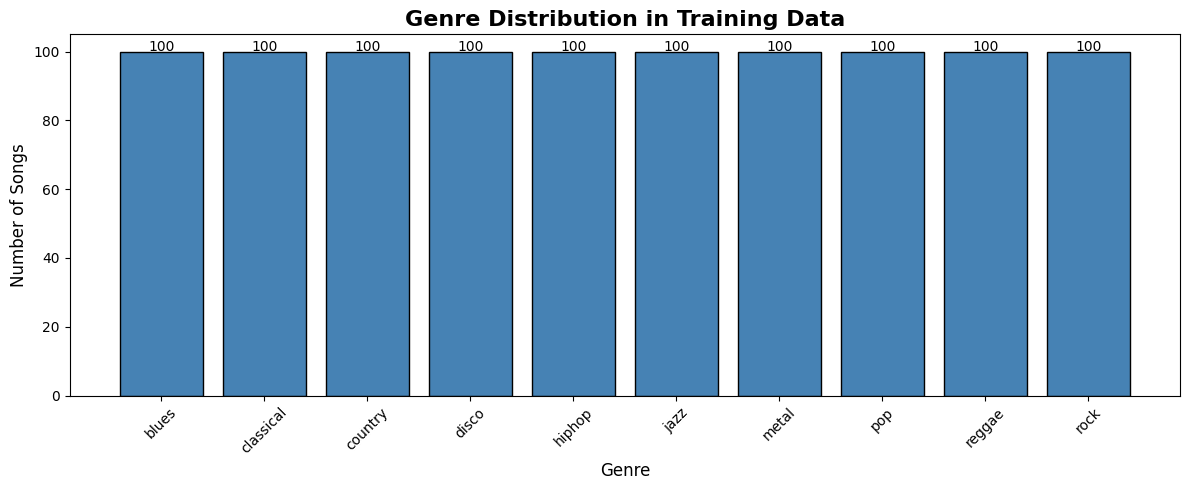

Genre distribution plotted and logged to W&B!


In [7]:
# start wandb run for EDA
wandb.init(
    project = "23f3000162-t12026",
    name    = "milestone1-eda",
    config  = {
        "sample_rate": SAMPLE_RATE,
        "genres"     : GENRES,
        "total_songs": sum(len(v) for v in song_index.values())
    }
)

# genre distribution
genre_counts = {genre: len(song_index[genre]) for genre in GENRES}

plt.figure(figsize=(12, 5))
bars = plt.bar(genre_counts.keys(), genre_counts.values(), color="steelblue", edgecolor="black")
plt.title("Genre Distribution in Training Data", fontsize=16, fontweight="bold")
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Number of Songs", fontsize=12)
plt.xticks(rotation=45)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(int(bar.get_height())), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("genre_distribution.png", dpi=150)
plt.show()

# log to wandb
wandb.log({"genre_distribution": wandb.Image("genre_distribution.png")})
wandb.log({f"songs_{genre}": count for genre, count in genre_counts.items()})
print("Genre distribution plotted and logged to W&B!")

Analyzing audio lengths (this may take a few minutes)...


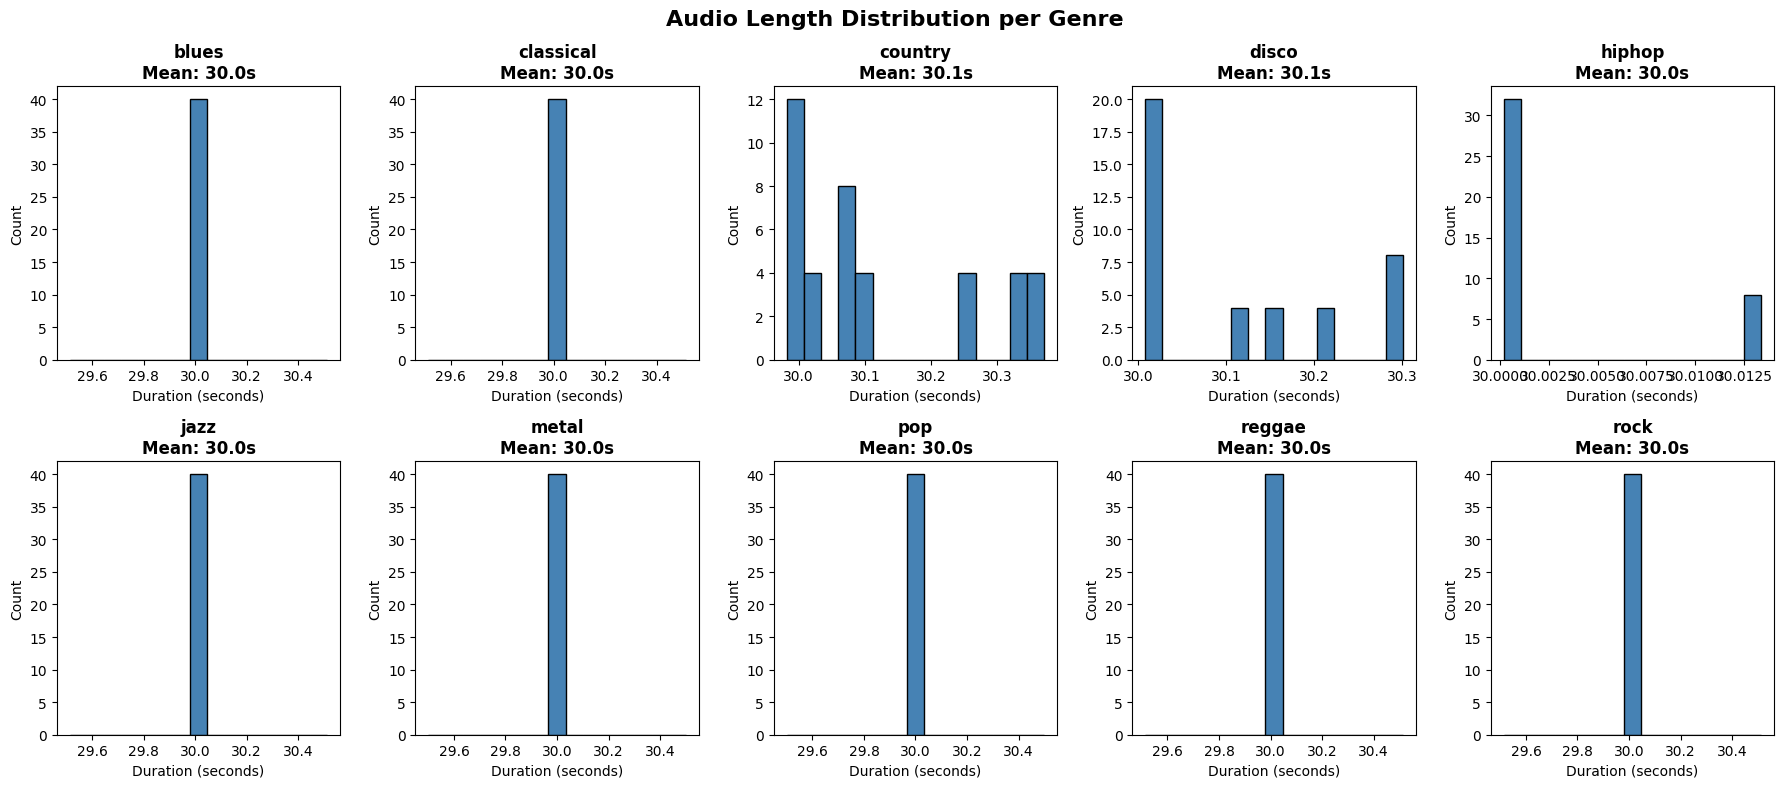

Audio length analysis done!


In [8]:
print("Analyzing audio lengths (this may take a few minutes)...")

audio_lengths = {genre: [] for genre in GENRES}

for genre in GENRES:
    for song_path in song_index[genre][:10]:  # sample 10 songs per genre
        for stem in REQUIRED_STEMS:
            path = os.path.join(song_path, stem)
            y, _ = librosa.load(path, sr=SAMPLE_RATE)
            audio_lengths[genre].append(len(y) / SAMPLE_RATE)

# plot
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, genre in enumerate(GENRES):
    lengths = audio_lengths[genre]
    axes[i].hist(lengths, bins=15, color="steelblue", edgecolor="black")
    axes[i].set_title(f"{genre}\nMean: {np.mean(lengths):.1f}s", fontweight="bold")
    axes[i].set_xlabel("Duration (seconds)")
    axes[i].set_ylabel("Count")

plt.suptitle("Audio Length Distribution per Genre", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("audio_lengths.png", dpi=150)
plt.show()

# log to wandb
wandb.log({"audio_lengths": wandb.Image("audio_lengths.png")})
avg_lengths = {genre: np.mean(audio_lengths[genre]) for genre in GENRES}
wandb.log({f"avg_length_{genre}": v for genre, v in avg_lengths.items()})
print("Audio length analysis done!")

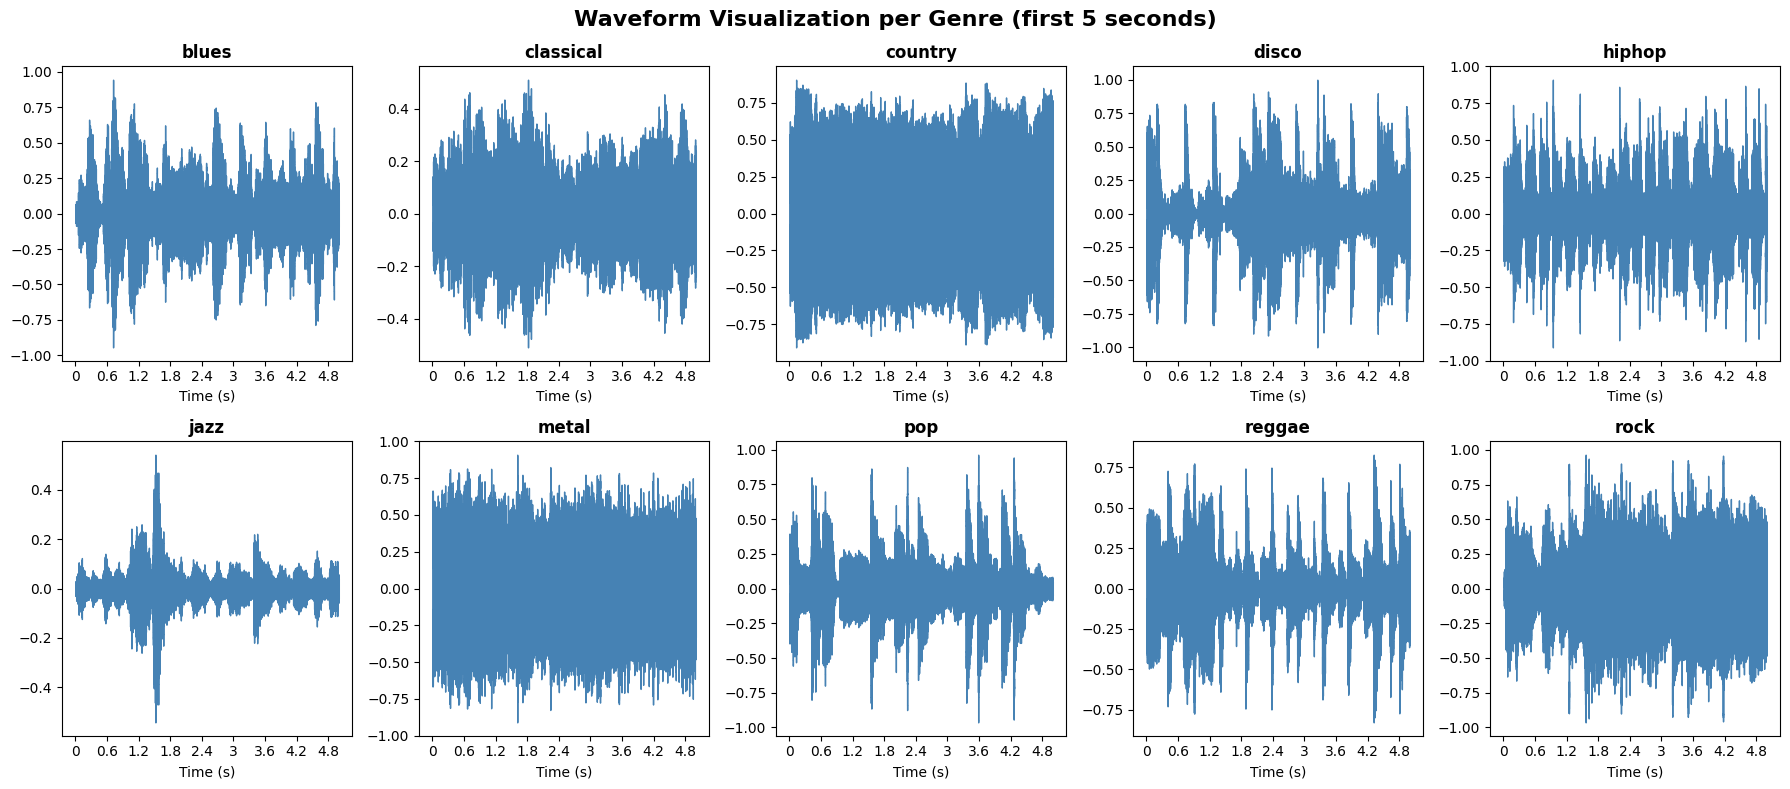

Waveform visualization done!


In [9]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, genre in enumerate(GENRES):
    song_path = song_index[genre][0]
    # load and mix all stems
    mixed = None
    for stem in REQUIRED_STEMS:
        y, _ = librosa.load(os.path.join(song_path, stem), sr=SAMPLE_RATE)
        mixed = y if mixed is None else mixed + y
    mixed = mixed / (np.max(np.abs(mixed)) + 1e-6)
    # plot first 5 seconds
    samples = SAMPLE_RATE * 5
    librosa.display.waveshow(mixed[:samples], sr=SAMPLE_RATE, ax=axes[i], color="steelblue")
    axes[i].set_title(f"{genre}", fontweight="bold", fontsize=12)
    axes[i].set_xlabel("Time (s)")

plt.suptitle("Waveform Visualization per Genre (first 5 seconds)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("waveforms.png", dpi=150)
plt.show()

wandb.log({"waveforms": wandb.Image("waveforms.png")})
print("Waveform visualization done!")

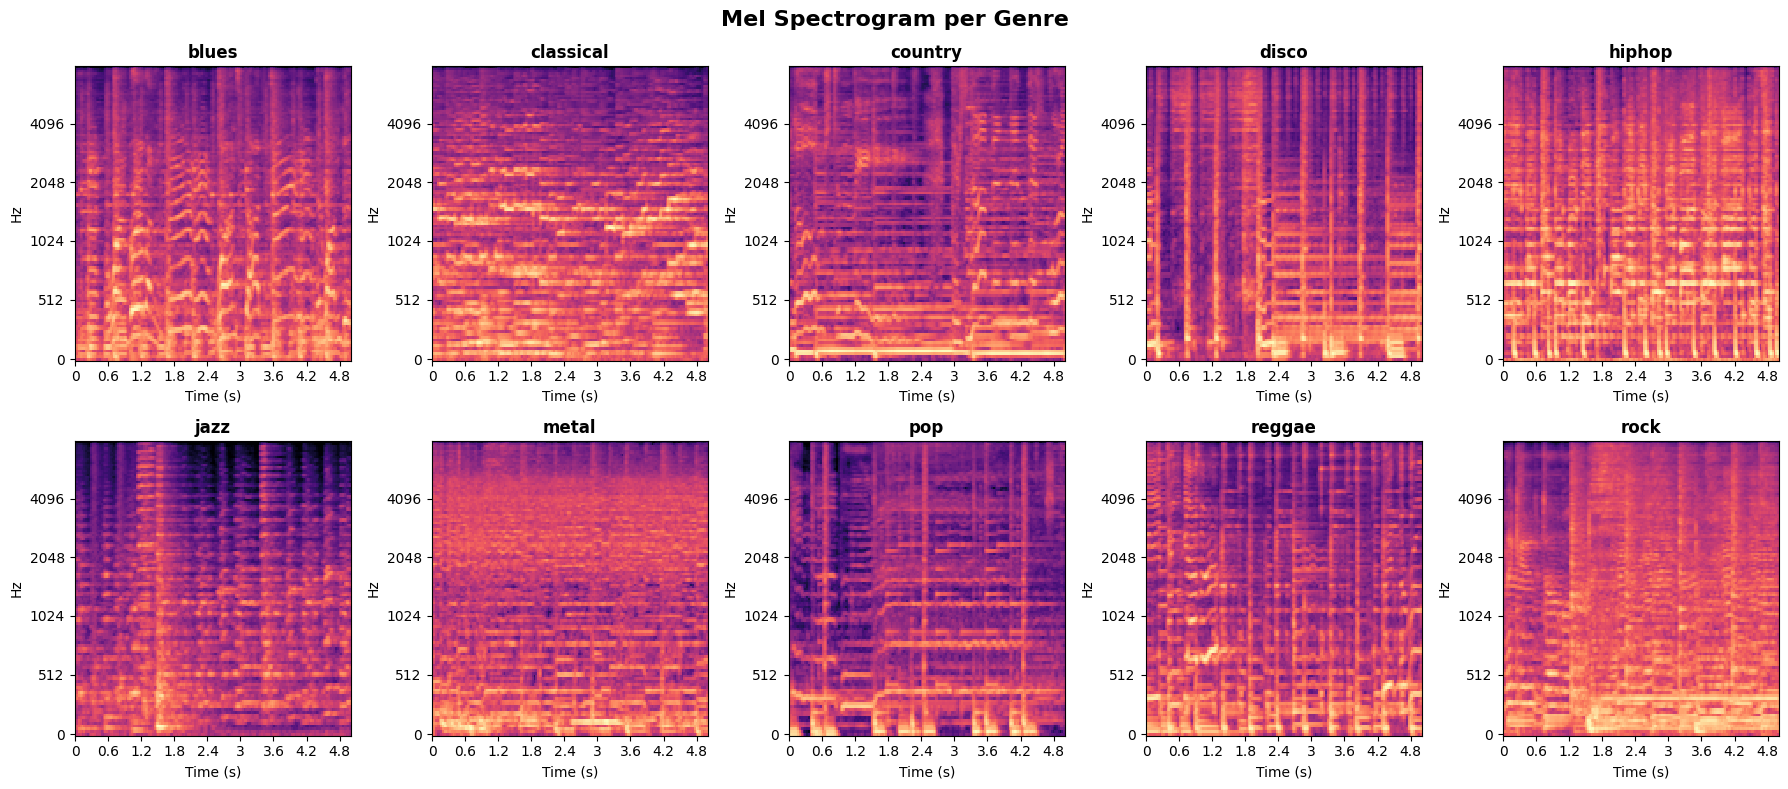

Spectrogram visualization done!


In [10]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, genre in enumerate(GENRES):
    song_path = song_index[genre][0]
    mixed = None
    for stem in REQUIRED_STEMS:
        y, _ = librosa.load(os.path.join(song_path, stem), sr=SAMPLE_RATE)
        mixed = y if mixed is None else mixed + y
    mixed = mixed / (np.max(np.abs(mixed)) + 1e-6)

    # mel spectrogram
    mel_spec = librosa.feature.melspectrogram(y=mixed[:SAMPLE_RATE*5], sr=SAMPLE_RATE, n_mels=128)
    mel_db   = librosa.power_to_db(mel_spec, ref=np.max)

    img = librosa.display.specshow(mel_db, sr=SAMPLE_RATE, x_axis="time",
                                   y_axis="mel", ax=axes[i], cmap="magma")
    axes[i].set_title(f"{genre}", fontweight="bold", fontsize=12)
    axes[i].set_xlabel("Time (s)")

plt.suptitle("Mel Spectrogram per Genre", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("spectrograms.png", dpi=150)
plt.show()

wandb.log({"spectrograms": wandb.Image("spectrograms.png")})
print("Spectrogram visualization done!")

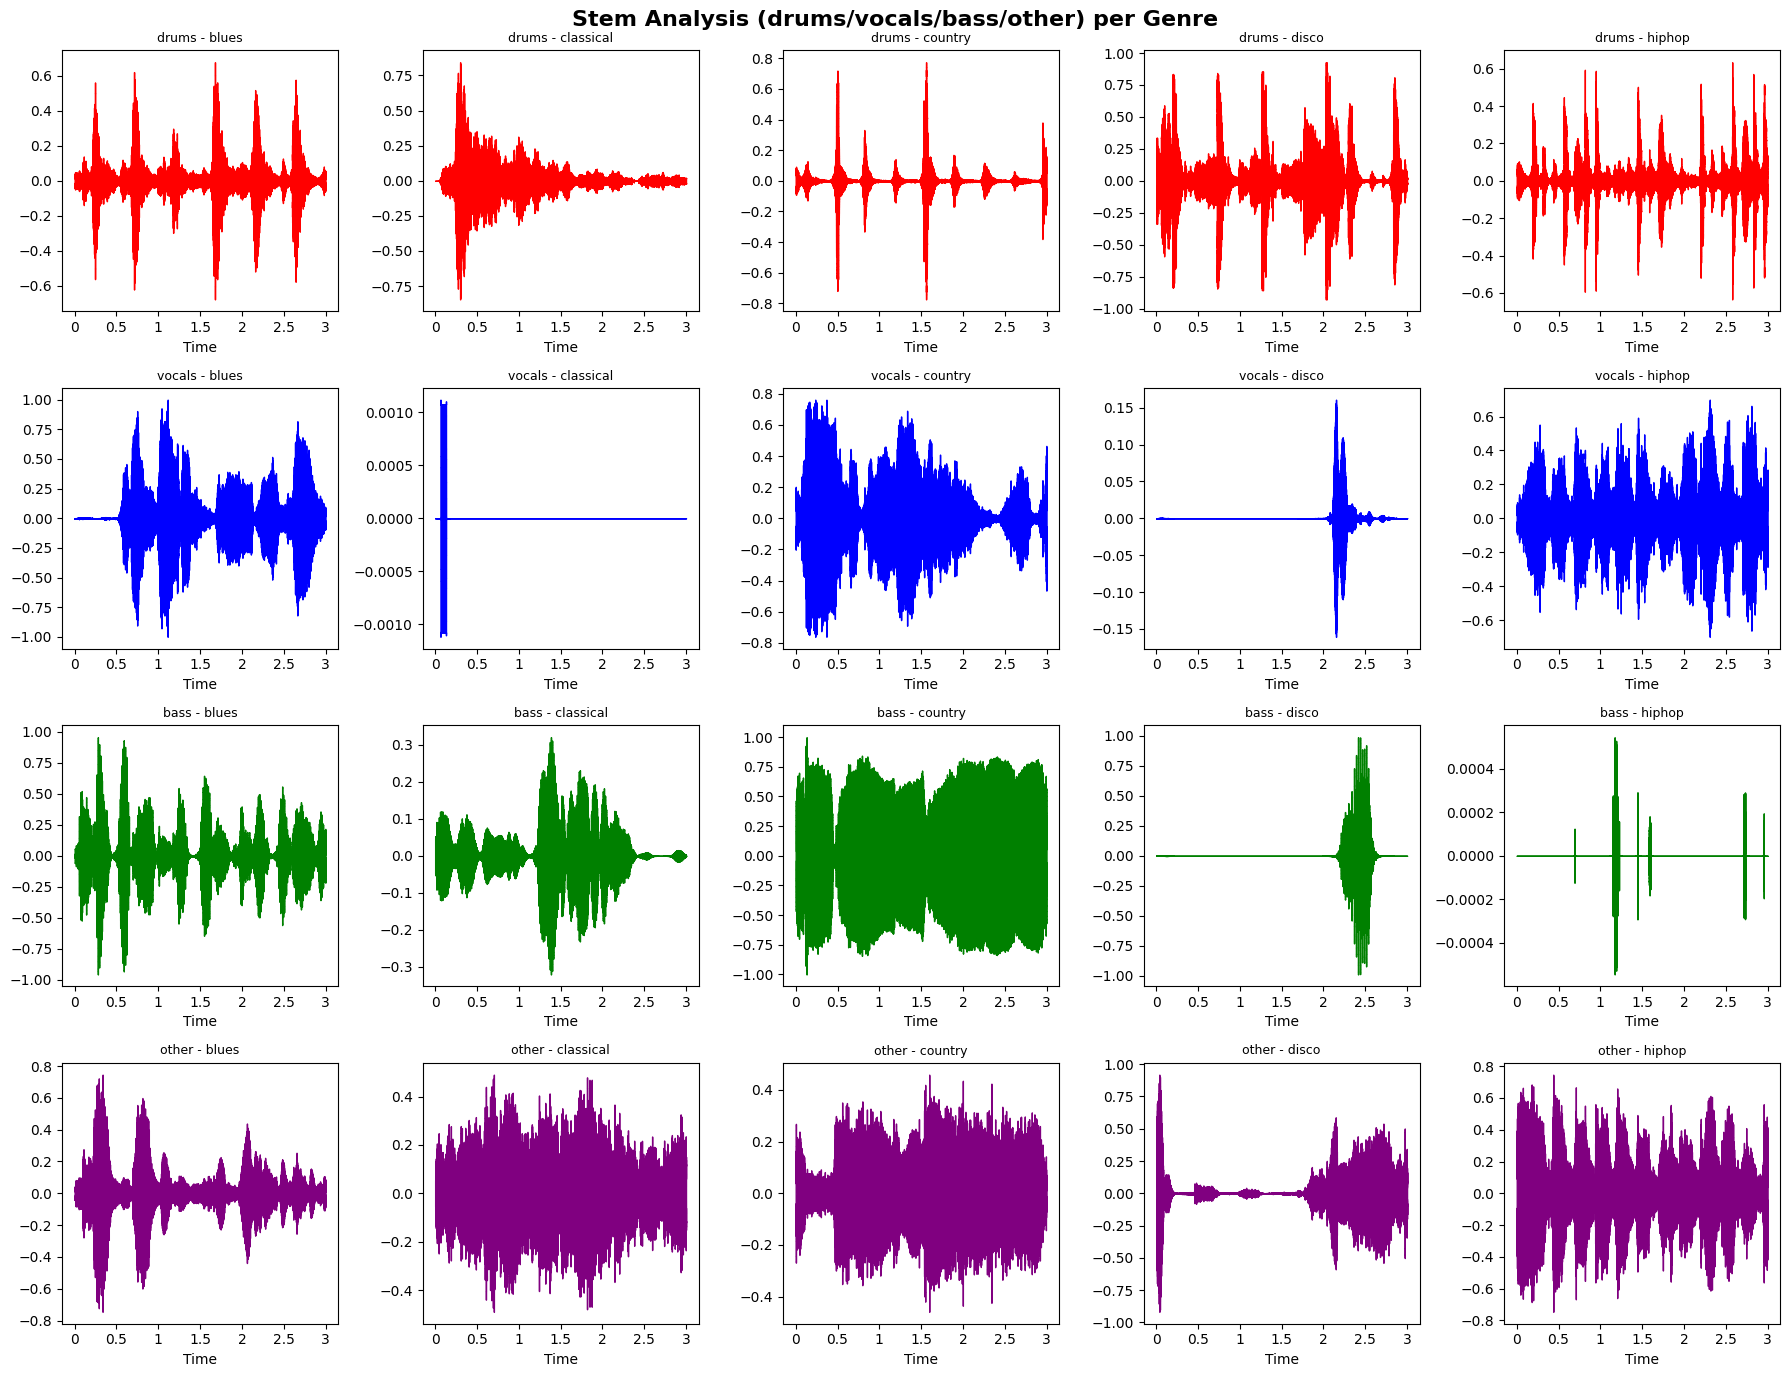

Stem analysis done!


In [11]:
fig, axes = plt.subplots(4, 5, figsize=(18, 14))
stem_colors = {"drums.wav": "red", "vocals.wav": "blue",
               "bass.wav": "green", "other.wav": "purple"}

for j, stem in enumerate(REQUIRED_STEMS):
    for i, genre in enumerate(GENRES[:5]):
        song_path = song_index[genre][0]
        y, _ = librosa.load(os.path.join(song_path, stem), sr=SAMPLE_RATE)
        y = y / (np.max(np.abs(y)) + 1e-6)
        librosa.display.waveshow(y[:SAMPLE_RATE*3], sr=SAMPLE_RATE,
                                 ax=axes[j][i], color=stem_colors[stem])
        axes[j][i].set_title(f"{stem.replace('.wav','')} - {genre}", fontsize=9)

plt.suptitle("Stem Analysis (drums/vocals/bass/other) per Genre", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("stem_analysis.png", dpi=150)
plt.show()

wandb.log({"stem_analysis": wandb.Image("stem_analysis.png")})
print("Stem analysis done!")

ESC-50 categories: 50
ESC-50 total files: 2000


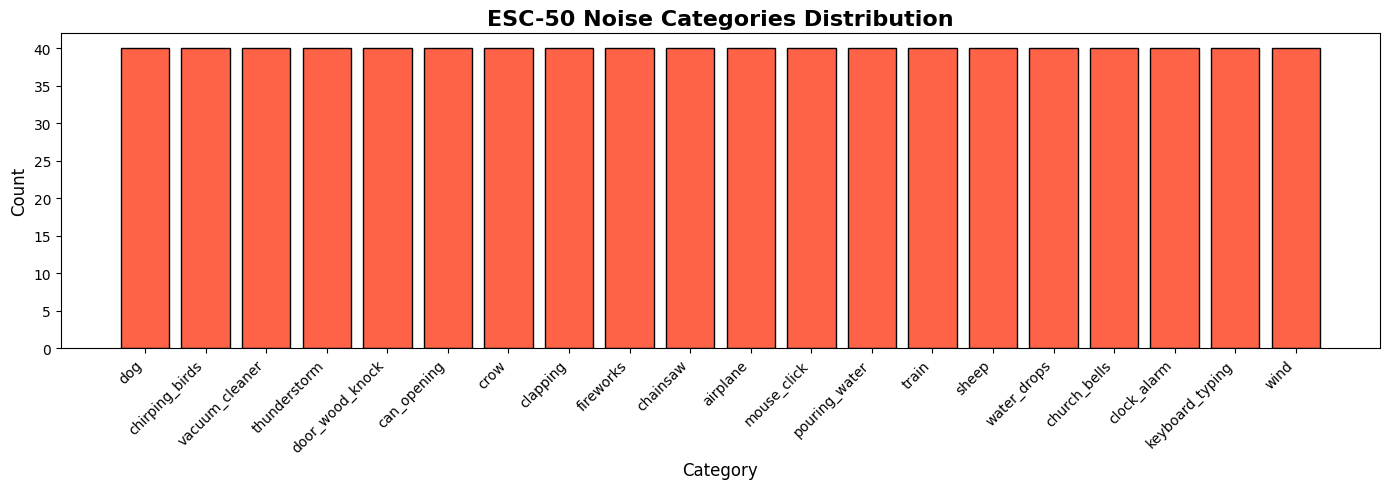

ESC-50 noise analysis done!


In [12]:
# load ESC-50 metadata
esc_meta = pd.read_csv(ESC_META)
print("ESC-50 categories:", esc_meta["category"].nunique())
print("ESC-50 total files:", len(esc_meta))

# plot top noise categories
top_categories = esc_meta["category"].value_counts().head(20)

plt.figure(figsize=(14, 5))
bars = plt.bar(top_categories.index, top_categories.values, color="tomato", edgecolor="black")
plt.title("ESC-50 Noise Categories Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Category", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("esc50_distribution.png", dpi=150)
plt.show()

wandb.log({"esc50_distribution": wandb.Image("esc50_distribution.png")})
print("ESC-50 noise analysis done!")

In [13]:
print("="*50)
print("EDA SUMMARY")
print("="*50)
print(f"Total genres          : {len(GENRES)}")
print(f"Total training songs  : {sum(len(v) for v in song_index.values())}")
print(f"Stems per song        : {len(REQUIRED_STEMS)}")
print(f"Total stem files      : {sum(len(v) for v in song_index.values()) * len(REQUIRED_STEMS)}")
print(f"ESC-50 noise files    : {len(esc_meta)}")
print(f"Test mashup files     : 3020")
print(f"Sample rate           : {SAMPLE_RATE} Hz")
print("="*50)

# log summary to wandb
wandb.log({
    "total_genres"        : len(GENRES),
    "total_training_songs": sum(len(v) for v in song_index.values()),
    "stems_per_song"      : len(REQUIRED_STEMS),
    "esc50_noise_files"   : len(esc_meta),
    "test_files"          : 3020
})

wandb.finish()
print("\nMilestone 1 - EDA Complete!")
print("W&B run finished!")

wandb: updating run metadata


EDA SUMMARY
Total genres          : 10
Total training songs  : 1000
Stems per song        : 4
Total stem files      : 4000
ESC-50 noise files    : 2000
Test mashup files     : 3020
Sample rate           : 16000 Hz


wandb: uploading history steps 6-8, summary, console lines 5-19
wandb: 
wandb: Run history:
wandb:     avg_length_blues ▁
wandb: avg_length_classical ▁
wandb:   avg_length_country ▁
wandb:     avg_length_disco ▁
wandb:    avg_length_hiphop ▁
wandb:      avg_length_jazz ▁
wandb:     avg_length_metal ▁
wandb:       avg_length_pop ▁
wandb:    avg_length_reggae ▁
wandb:      avg_length_rock ▁
wandb:                  +15 ...
wandb: 
wandb: Run summary:
wandb:     avg_length_blues 30.01338
wandb: avg_length_classical 30.01338
wandb:   avg_length_country 30.11939
wandb:     avg_length_disco 30.11483
wandb:    avg_length_hiphop 30.00283
wandb:      avg_length_jazz 30.01338
wandb:     avg_length_metal 30.00019
wandb:       avg_length_pop 30.00019
wandb:    avg_length_reggae 30.01338
wandb:      avg_length_rock 30.01338
wandb:                  +15 ...
wandb: 
wandb: 🚀 View run milestone1-eda at: https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026/runs/r0iv7xro
wandb: ⭐️ View project at: htt


Milestone 1 - EDA Complete!
W&B run finished!


In [14]:

# MILESTONE 2 - Classical ML Baseline
# Models: LightGBM, XGBoost, CatBoost
# Features: MFCCs, Spectral Features
# Evaluation: Macro F1 Score

print("Milestone 2 - Classical ML Baseline Started")

Milestone 2 - Classical ML Baseline Started


In [15]:
def extract_features(song_path, sr=SAMPLE_RATE):
    mixed = None
    for stem in REQUIRED_STEMS:
        path = os.path.join(song_path, stem)
        y, _ = librosa.load(path, sr=sr, mono=True)
        # take first 20 seconds only
        y = y[:sr*20]
        mixed = y if mixed is None else mixed + y

    # normalize
    mixed = mixed / (np.max(np.abs(mixed)) + 1e-6)

    # 1. MFCCs (40 coefficients)
    mfcc = librosa.feature.mfcc(y=mixed, sr=sr, n_mfcc=40)
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std  = np.std(mfcc, axis=1)

    # 2. Chroma features
    chroma = librosa.feature.chroma_stft(y=mixed, sr=sr)
    chroma_mean = np.mean(chroma, axis=1)
    chroma_std  = np.std(chroma, axis=1)

    # 3. Spectral contrast
    contrast = librosa.feature.spectral_contrast(y=mixed, sr=sr)
    contrast_mean = np.mean(contrast, axis=1)

    # 4. Mel spectrogram
    mel = librosa.feature.melspectrogram(y=mixed, sr=sr, n_mels=64)
    mel_mean = np.mean(mel, axis=1)

    # 5. Zero crossing rate
    zcr = librosa.feature.zero_crossing_rate(mixed)
    zcr_mean = np.mean(zcr)

    # 6. RMS energy
    rms = librosa.feature.rms(y=mixed)
    rms_mean = np.mean(rms)

    # combine all features
    features = np.concatenate([
        mfcc_mean, mfcc_std,
        chroma_mean, chroma_std,
        contrast_mean,
        mel_mean,
        [zcr_mean, rms_mean]
    ])
    return features

print("Feature extraction function ready!")
print("Testing on one song...")
test_features = extract_features(song_index["blues"][0])
print(f"Feature vector size: {test_features.shape}")

Feature extraction function ready!
Testing on one song...
Feature vector size: (177,)


In [16]:

GENRES = ["blues","classical","country","disco","hiphop",
          "jazz","metal","pop","reggae","rock"]

label2id = {g: i for i, g in enumerate(GENRES)}
id2label = {i: g for g, i in label2id.items()}
NUM_LABELS = len(GENRES)

SAMPLE_RATE    = 16000
REQUIRED_STEMS = ["drums.wav","vocals.wav","bass.wav","other.wav"]

print("Labels defined!")
print(label2id)


Labels defined!
{'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}


In [17]:
from tqdm import tqdm

print("Extracting features from all songs...")
print("This will take 10-15 minutes...\n")

X = []
y = []

for genre in GENRES:
    print(f"Processing {genre}...")
    for song_path in tqdm(song_index[genre]):
        try:
            features = extract_features(song_path)
            X.append(features)
            y.append(label2id[genre])
        except Exception as e:
            print(f"Error: {song_path} - {e}")
            continue

X = np.array(X)
y = np.array(y)

print(f"\nFeature matrix shape : {X.shape}")
print(f"Labels shape         : {y.shape}")
print(f"Total samples        : {len(X)}")

Extracting features from all songs...
This will take 10-15 minutes...

Processing blues...


100%|██████████| 100/100 [00:55<00:00,  1.82it/s]


Processing classical...


100%|██████████| 100/100 [00:50<00:00,  1.98it/s]


Processing country...


...

Processing reggae...


100%|██████████| 100/100 [00:51<00:00,  1.92it/s]


Processing rock...


100%|██████████| 100/100 [00:52<00:00,  1.91it/s]


Feature matrix shape : (1000, 177)
Labels shape         : (1000,)
Total samples        : 1000


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

print(f"Train size : {X_train_scaled.shape}")
print(f"Val size   : {X_val_scaled.shape}")
print("Features scaled successfully")

Train size : (850, 177)
Val size   : (150, 177)
Features scaled successfully


In [19]:
import lightgbm as lgb

# start wandb run for LightGBM
wandb.init(
    project = "23f3000162-t12026",
    name    = "milestone2-lightgbm",
    config  = {
        "model"        : "LightGBM",
        "n_estimators" : 500,
        "learning_rate": 0.05,
        "num_leaves"   : 63,
        "feature_size" : X_train.shape[1]
    }
)

lgb_model = lgb.LGBMClassifier(
    n_estimators      = 500,
    learning_rate     = 0.05,
    num_leaves        = 63,
    random_state      = 42,
    n_jobs            = -1,
    min_gain_to_split = 0.01,   # stops useless splits
    verbose           = -1       # removes all warnings
)

lgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)]
)

# evaluate
lgb_preds = lgb_model.predict(X_val_scaled)
lgb_f1    = f1_score(y_val, lgb_preds, average="macro")

print(f"\nLightGBM Val F1: {lgb_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, lgb_preds, target_names=GENRES))

# log to wandb
wandb.log({"val_f1": lgb_f1})
wandb.finish()
print("LightGBM done")

wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260228_233904-5upbdfjz
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run milestone2-lightgbm
wandb: ⭐️ View project at https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026
wandb: 🚀 View run at https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026/runs/5upbdfjz
wandb: updating run metadata



LightGBM Val F1: 0.7201

Classification Report:
              precision    recall  f1-score   support

       blues       0.77      0.67      0.71        15
   classical       0.88      0.93      0.90        15
     country       0.67      0.80      0.73        15
       disco       0.77      0.67      0.71        15
      hiphop       0.58      0.73      0.65        15
        jazz       1.00      0.87      0.93        15
       metal       0.75      0.60      0.67        15
         pop       0.75      0.80      0.77        15
      reggae       0.59      0.67      0.62        15
        rock       0.54      0.47      0.50        15

    accuracy                           0.72       150
   macro avg       0.73      0.72      0.72       150
weighted avg       0.73      0.72      0.72       150



wandb: 
wandb: Run history:
wandb: val_f1 ▁
wandb: 
wandb: Run summary:
wandb: val_f1 0.72006
wandb: 
wandb: 🚀 View run milestone2-lightgbm at: https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026/runs/5upbdfjz
wandb: ⭐️ View project at: https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260228_233904-5upbdfjz/logs


LightGBM done


In [20]:
import xgboost as xgb

wandb.init(
    project = "23f3000162-t12026",
    name    = "milestone2-xgboost",
    config  = {
        "model"        : "XGBoost",
        "n_estimators" : 300,
        "learning_rate": 0.05,
        "max_depth"    : 6
    }
)

xgb_model = xgb.XGBClassifier(
    n_estimators  = 300,
    learning_rate = 0.05,
    max_depth     = 6,
    random_state  = 42,
    n_jobs        = -1,
    use_label_encoder = False,
    eval_metric       = "mlogloss"
)

xgb_model.fit(X_train_scaled, y_train)

xgb_preds = xgb_model.predict(X_val_scaled)
xgb_f1    = f1_score(y_val, xgb_preds, average="macro")

print(f"\nXGBoost Val F1: {xgb_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, xgb_preds, target_names=GENRES))

wandb.log({"val_f1": xgb_f1})
wandb.finish()
print("XGBoost done")

wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260228_233911-yqoduh4k
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run milestone2-xgboost
wandb: ⭐️ View project at https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026
wandb: 🚀 View run at https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026/runs/yqoduh4k
wandb: updating run metadata



XGBoost Val F1: 0.7278

Classification Report:
              precision    recall  f1-score   support

       blues       1.00      0.80      0.89        15
   classical       0.88      0.93      0.90        15
     country       0.60      0.80      0.69        15
       disco       0.71      0.67      0.69        15
      hiphop       0.56      0.67      0.61        15
        jazz       0.93      0.87      0.90        15
       metal       0.82      0.60      0.69        15
         pop       0.76      0.87      0.81        15
      reggae       0.71      0.67      0.69        15
        rock       0.43      0.40      0.41        15

    accuracy                           0.73       150
   macro avg       0.74      0.73      0.73       150
weighted avg       0.74      0.73      0.73       150



wandb: uploading history steps 0-0, summary, console lines 0-19
wandb: 
wandb: Run history:
wandb: val_f1 ▁
wandb: 
wandb: Run summary:
wandb: val_f1 0.72784
wandb: 
wandb: 🚀 View run milestone2-xgboost at: https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026/runs/yqoduh4k
wandb: ⭐️ View project at: https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260228_233911-yqoduh4k/logs


XGBoost done


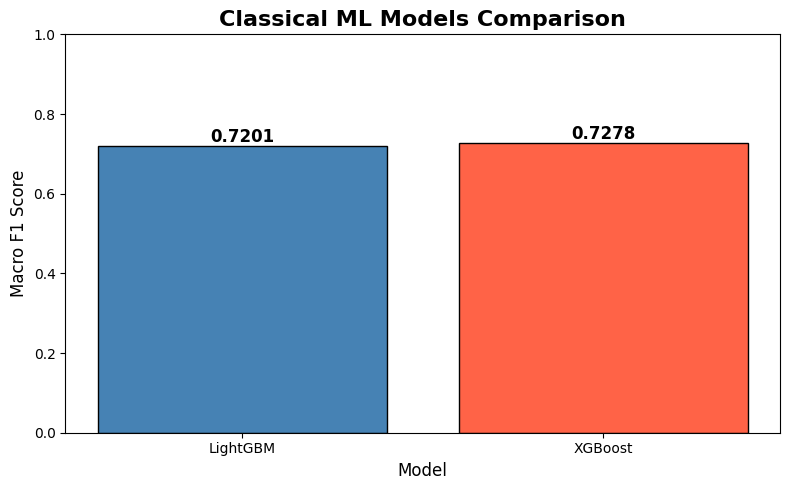

wandb: setting up run j1etdf69
wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260228_233933-j1etdf69
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run milestone2-comparison
wandb: ⭐️ View project at https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026
wandb: 🚀 View run at https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026/runs/j1etdf69
wandb: updating run metadata
wandb: uploading history steps 0-0, summary
wandb: 
wandb: Run history:
wandb: best_classical_ml_f1 ▁
wandb:          lightgbm_f1 ▁
wandb:           xgboost_f1 ▁
wandb: 
wandb: Run summary:
wandb:    best_classical_ml_f1 0.72784
wandb: best_classical_ml_model XGBoost
wandb:             lightgbm_f1 0.72006
wandb:              xgboost_f1 0.72784
wandb: 
wandb: 🚀 View run milestone2-comparison at: https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026/runs/j1etdf69
wandb: ⭐️ View project at: https://wandb.ai/23f3000162-iit-madras/23f30001


summery
LightGBM F1 : 0.7201
XGBoost F1  : 0.7278
Best Model  : XGBoost
Best F1     : 0.7278
done


In [21]:
# compare all classical ml models
models     = ["LightGBM", "XGBoost"]
f1_scores  = [lgb_f1, xgb_f1]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, f1_scores, color=["steelblue","tomato"], edgecolor="black")
plt.title("Classical ML Models Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Model", fontsize=12)
plt.ylabel("Macro F1 Score", fontsize=12)
plt.ylim(0, 1.0)
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{score:.4f}", ha="center", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("classical_ml_comparison.png", dpi=150)
plt.show()

# log comparison to wandb
wandb.init(
    project = "23f3000162-t12026",
    name    = "milestone2-comparison"
)
wandb.log({
    "lightgbm_f1"             : lgb_f1,
    "xgboost_f1"              : xgb_f1,
    "best_classical_ml_f1"    : max(f1_scores),
    "best_classical_ml_model" : models[np.argmax(f1_scores)],
    "comparison_plot"         : wandb.Image("classical_ml_comparison.png")
})
wandb.finish()

print("\n" + "="*50)
print("summery")
print("="*50)
print(f"LightGBM F1 : {lgb_f1:.4f}")
print(f"XGBoost F1  : {xgb_f1:.4f}")
print(f"Best Model  : {models[np.argmax(f1_scores)]}")
print(f"Best F1     : {max(f1_scores):.4f}")
print("="*50)
print("done")




In [22]:
print("Milestone 3 - CNN from Scratch Started")

Milestone 3 - CNN from Scratch Started


In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchmetrics.classification import MulticlassF1Score
from tqdm import tqdm

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
EPOCHS_CNN = 10
LR_CNN     = 1e-3

print("Device:", DEVICE)
print("CNN training setup ready")

Device: cuda
CNN training setup ready


In [24]:
class CNNDataset(Dataset):
    def __init__(self, song_index, augment=False):
        self.samples  = []
        self.augment  = augment
        for genre in GENRES:
            for song_path in song_index[genre]:
                self.samples.append((genre, song_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        genre, song_path = self.samples[idx]

        # load and mix all stems
        mixed = None
        for stem in REQUIRED_STEMS:
            y, _ = librosa.load(os.path.join(song_path, stem),
                                sr=SAMPLE_RATE, mono=True)
            y = y[:SAMPLE_RATE * 20]  # first 20 seconds
            mixed = y if mixed is None else mixed + y

        # normalize
        mixed = mixed / (np.max(np.abs(mixed)) + 1e-6)

        # augmentation for training
        if self.augment:
            # random gain
            mixed = mixed * random.uniform(0.7, 1.3)
            # add small noise
            mixed = mixed + np.random.randn(len(mixed)) * 0.005

        # mel spectrogram → 2D image for CNN
        mel = librosa.feature.melspectrogram(
            y=mixed, sr=SAMPLE_RATE, n_mels=128, n_fft=2048, hop_length=512
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # normalize to 0-1
        mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)

        # shape → (1, 128, T) → CNN input
        mel_tensor = torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0)

        return mel_tensor, torch.tensor(label2id[genre], dtype=torch.long)

print("CNN Dataset class defined!")

CNN Dataset class defined!


In [25]:
class GenreCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(GenreCNN, self).__init__()

        # Block 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25)
        )

        # Block 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25)
        )

        # Block 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25)
        )

        # Block 4
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.25)
        )

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d(1)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

# test model
cnn_model = GenreCNN(num_classes=NUM_LABELS).to(DEVICE)
print("CNN Model Architecture:")
print(cnn_model)
print(f"\nTotal parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")

CNN Model Architecture:
GenreCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dro

In [26]:
# train val split
cnn_train_index = {}
cnn_val_index   = {}

for genre in GENRES:
    songs = song_index[genre][:]
    random.shuffle(songs)
    split = int(0.85 * len(songs))
    cnn_train_index[genre] = songs[:split]
    cnn_val_index[genre]   = songs[split:]

cnn_train_dataset = CNNDataset(cnn_train_index, augment=True)
cnn_val_dataset   = CNNDataset(cnn_val_index,   augment=False)

cnn_train_loader = DataLoader(
    cnn_train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 2,
    pin_memory  = True
)

cnn_val_loader = DataLoader(
    cnn_val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True
)

print(f"Train samples : {len(cnn_train_dataset)}")
print(f"Val samples   : {len(cnn_val_dataset)}")
print(f"Train batches : {len(cnn_train_loader)}")
print(f"Val batches   : {len(cnn_val_loader)}")
print("CNN DataLoaders ready!")

Train samples : 850
Val samples   : 150
Train batches : 54
Val batches   : 10
CNN DataLoaders ready!


In [27]:
# improved hyperparameters
EPOCHS_CNN = 15
LR_CNN     = 3e-4

wandb.init(
    project = "23f3000162-t12026",
    name    = "milestone3-cnn-improved",
    config  = {
        "model"      : "CNN improved",
        "epochs"     : EPOCHS_CNN,
        "lr"         : LR_CNN,
        "batch_size" : BATCH_SIZE,
        "n_mels"     : 128,
        "duration"   : 20,
        "improvement": "cosine warmup + label smoothing"
    }
)

# reset model with fresh weights
cnn_model = GenreCNN(num_classes=NUM_LABELS).to(DEVICE)

optimizer = torch.optim.AdamW(
    cnn_model.parameters(),
    lr           = LR_CNN,
    weight_decay = 0.01
)

# warmup + cosine decay scheduler
from transformers import get_cosine_schedule_with_warmup
total_steps  = len(cnn_train_loader) * EPOCHS_CNN
warmup_steps = total_steps // 10

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

criterion = nn.CrossEntropyLoss(label_smoothing=0.15)
f1_metric = MulticlassF1Score(num_classes=NUM_LABELS, average="macro").to(DEVICE)

best_val_f1  = 0
patience     = 4
patience_cnt = 0

print(f"\n{'='*50}")
print(f"Improved CNN Training ({EPOCHS_CNN} epochs)")
print(f"{'='*50}\n")

for epoch in range(EPOCHS_CNN):

    # training
    cnn_model.train()
    f1_metric.reset()
    train_loss = 0

    for mel, labels in tqdm(cnn_train_loader, desc=f"Epoch {epoch+1} Train"):
        mel    = mel.to(DEVICE)
        labels = labels.to(DEVICE)

        # mixup augmentation
        if random.random() < 0.3:
            lam    = random.uniform(0.3, 0.7)
            idx    = torch.randperm(mel.size(0)).to(DEVICE)
            mel    = lam * mel + (1 - lam) * mel[idx]

        optimizer.zero_grad()
        outputs = cnn_model(mel)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(cnn_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        f1_metric.update(preds, labels)

    train_f1   = f1_metric.compute().item()
    train_loss = train_loss / len(cnn_train_loader)

    # validation
    cnn_model.eval()
    f1_metric.reset()

    with torch.no_grad():
        for mel, labels in tqdm(cnn_val_loader, desc=f"Epoch {epoch+1} Val"):
            mel    = mel.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = cnn_model(mel)
            preds   = torch.argmax(outputs, dim=1)
            f1_metric.update(preds, labels)

    val_f1 = f1_metric.compute().item()

    print(f"\nEpoch {epoch+1}/{EPOCHS_CNN}")
    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Train F1   : {train_f1:.4f}")
    print(f"  Val F1     : {val_f1:.4f}")

    wandb.log({
        "epoch"     : epoch + 1,
        "train_loss": train_loss,
        "train_f1"  : train_f1,
        "val_f1"    : val_f1,
        "lr"        : optimizer.param_groups[0]["lr"]
    })

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(cnn_model.state_dict(), "/kaggle/working/best_cnn_model.pth")
        patience_cnt = 0
        print("  [Saved best CNN model]")
    else:
        patience_cnt += 1
        if patience_cnt >= patience:
            print("  Early stopping triggered!")
            break

wandb.log({"best_val_f1": best_val_f1})
wandb.finish()

print(f"\n{'='*50}")
print(f"Milestone 3 Complete!")
print(f"Best CNN Val F1: {best_val_f1:.4f}")
print(f"{'='*50}")


wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260228_233956-blej6rot
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run milestone3-cnn-improved
wandb: ⭐️ View project at https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026
wandb: 🚀 View run at https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026/runs/blej6rot



Improved CNN Training (15 epochs)



Epoch 1 Val: 100%|██████████| 10/10 [00:26<00:00,  2.64s/it]



Epoch 1/15
  Train Loss : 2.3193
  Train F1   : 0.0824
  Val F1     : 0.1014
  [Saved best CNN model]


Epoch 2 Val: 100%|██████████| 10/10 [00:26<00:00,  2.62s/it]


...


Epoch 4/15
  Train Loss : 2.2155
  Train F1   : 0.1291
  Val F1     : 0.0672


Epoch 5 Val: 100%|██████████| 10/10 [00:26<00:00,  2.67s/it]
wandb: updating run metadata



Epoch 5/15
  Train Loss : 2.2049
  Train F1   : 0.1644
  Val F1     : 0.0933
  Early stopping triggered!


wandb: 
wandb: Run history:
wandb: best_val_f1 ▁
wandb:       epoch ▁▃▅▆█
wandb:          lr ▁█▇▆▅
wandb:    train_f1 ▁▅▆▅█
wandb:  train_loss █▅▃▂▁
wandb:      val_f1 █▆▄▁▆
wandb: 
wandb: Run summary:
wandb: best_val_f1 0.10145
wandb:       epoch 5
wandb:          lr 0.00025
wandb:    train_f1 0.16439
wandb:  train_loss 2.2049
wandb:      val_f1 0.09327
wandb: 
wandb: 🚀 View run milestone3-cnn-improved at: https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026/runs/blej6rot
wandb: ⭐️ View project at: https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260228_233956-blej6rot/logs



Milestone 3 Complete!
Best CNN Val F1: 0.1014


In [28]:
print("Milestone 4 - CRNN (CNN + LSTM) Started")

Milestone 4 - CRNN (CNN + LSTM) Started


In [29]:
TARGET_SR       = 22050
TARGET_DURATION = 10
TARGET_LENGTH   = TARGET_SR * TARGET_DURATION
STEMS           = ["drums.wav", "vocals.wav", "bass.wav", "other.wav"]
genres_cnn      = sorted(os.listdir(GENRES_PATH))
label_map_cnn   = {g: i for i, g in enumerate(genres_cnn)}
noise_files_cnn = os.listdir(ESC_PATH)

print("CNN Config ready")
print("Genres:", genres_cnn)

CNN Config ready
Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [30]:
def cnn_load_audio(path):
    y, _ = librosa.load(path, sr=TARGET_SR)
    return y

def cnn_crop(y):
    if len(y) > TARGET_LENGTH:
        start = random.randint(0, len(y) - TARGET_LENGTH)
        return y[start:start + TARGET_LENGTH]
    return np.pad(y, (0, TARGET_LENGTH - len(y)))

def cnn_normalize(y):
    return y / (np.max(np.abs(y)) + 1e-6)

print("Audio helpers ready")

Audio helpers ready


In [31]:
def cnn_create_mashup(folder):
    genre      = folder.split("/")[-2]
    genre_path = os.path.join(GENRES_PATH, genre)
    songs      = os.listdir(genre_path)
    selected   = random.sample(songs, min(4, len(songs)))
    audios     = []
    for i, stem in enumerate(STEMS):
        path = os.path.join(genre_path, selected[i % len(selected)], stem)
        y    = cnn_load_audio(path)
        y    = cnn_crop(y)
        y    = cnn_normalize(y)
        y    = y * random.uniform(0.5, 1.5)
        audios.append(y)
    return cnn_normalize(np.sum(audios, axis=0))

def cnn_add_noise(y):
    for _ in range(random.randint(1, 3)):
        noise_path   = os.path.join(ESC_PATH, random.choice(noise_files_cnn))
        noise        = cnn_normalize(cnn_crop(cnn_load_audio(noise_path)))
        start        = random.randint(0, TARGET_LENGTH - 1)
        end          = min(start + len(noise), TARGET_LENGTH)
        y[start:end] += random.uniform(0.02, 0.08) * noise[:end-start]
    return cnn_normalize(y)

def cnn_extract_mel(y):
    mel    = librosa.feature.melspectrogram(y=y, sr=TARGET_SR, n_mels=128, hop_length=512)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)
    return mel_db

print("Mashup + Noise functions ready")

Mashup + Noise functions ready


In [32]:
from sklearn.model_selection import train_test_split

class CNNMashupDataset(Dataset):
    def __init__(self, folders, augment=False):
        self.folders = folders
        self.augment = augment

    def __len__(self):
        return len(self.folders)

    def __getitem__(self, idx):
        folder = self.folders[idx]
        genre  = folder.split("/")[-2]
        y      = cnn_create_mashup(folder)
        y      = cnn_add_noise(y)
        mel    = cnn_extract_mel(y)

        if self.augment:
            if random.random() > 0.5:
                f  = random.randint(5, 20)
                f0 = random.randint(0, mel.shape[0] - f)
                mel[f0:f0+f, :] = 0
            if random.random() > 0.5:
                t  = random.randint(10, 40)
                t0 = random.randint(0, mel.shape[1] - t)
                mel[:, t0:t0+t] = 0

        return torch.tensor(mel).unsqueeze(0).float(), torch.tensor(label_map_cnn[genre]).long()

print("CNN Dataset defined")

CNN Dataset defined


In [33]:
valid_folders = []
for g in genres_cnn:
    g_path = os.path.join(GENRES_PATH, g)
    for s in os.listdir(g_path):
        valid_folders.append(os.path.join(g_path, s))

train_f, val_f = train_test_split(
    valid_folders, test_size=0.2, random_state=42,
    stratify=[f.split("/")[-2] for f in valid_folders]
)

train_loader_cnn = DataLoader(CNNMashupDataset(train_f, augment=True),
                               batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
val_loader_cnn   = DataLoader(CNNMashupDataset(val_f, augment=False),
                               batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_f)}, Val: {len(val_f)}")

Train: 800, Val: 200


In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.2),
        )
        self.pool       = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))

cnn_model = CNNModel().to(device)
print(f"CNN Model ready! Parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")


CNN Model ready! Parameters: 422,986


In [35]:
from sklearn.metrics import f1_score as sk_f1

wandb.init(
    project = "23f3000162-t12026",
    name    = "milestone3-cnn",
    config  = {"model": "CNN", "epochs": 15, "lr": 1e-3, "batch_size": 16}
)

criterion    = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer    = torch.optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=0.01)
scheduler    = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)
best_cnn_f1  = 0
patience_cnt = 0

print("CNN Training setup ready!")

wandb: setting up run 3vvgwnza
wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260228_235445-3vvgwnza
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run milestone3-cnn
wandb: ⭐️ View project at https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026
wandb: 🚀 View run at https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026/runs/3vvgwnza


CNN Training setup ready!


In [36]:
EPOCHS_CNN = 15

for epoch in range(EPOCHS_CNN):
    cnn_model.train()
    train_loss, preds_all, labels_all = 0, [], []

    for x, y in tqdm(train_loader_cnn, desc=f"Epoch {epoch+1} Train"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out  = cnn_model(x)
        loss = criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(cnn_model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
        preds_all.extend(torch.argmax(out, 1).cpu().numpy())
        labels_all.extend(y.cpu().numpy())

    train_f1   = sk_f1(labels_all, preds_all, average="macro")
    train_loss /= len(train_loader_cnn)
    scheduler.step()

    cnn_model.eval()
    val_preds, val_labels = [], []

    with torch.no_grad():
        for x, y in tqdm(val_loader_cnn, desc=f"Epoch {epoch+1} Val"):
            x, y = x.to(device), y.to(device)
            val_preds.extend(torch.argmax(cnn_model(x), 1).cpu().numpy())
            val_labels.extend(y.cpu().numpy())

    val_f1 = sk_f1(val_labels, val_preds, average="macro")

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}")
    wandb.log({"epoch": epoch+1, "train_loss": train_loss, "train_f1": train_f1, "val_f1": val_f1})

    if val_f1 > best_cnn_f1:
        best_cnn_f1 = val_f1
        torch.save(cnn_model.state_dict(), "/kaggle/working/best_cnn_model.pth")
        patience_cnt = 0
        print("  [Saved best CNN model]")
    else:
        patience_cnt += 1
        if patience_cnt >= 4:
            print("Early stopping!")
            break

wandb.log({"best_val_f1": best_cnn_f1})
wandb.finish()
print(f"\nMilestone 3 Done! Best CNN Val F1: {best_cnn_f1:.4f}")


Epoch 1 Val: 100%|██████████| 13/13 [00:36<00:00,  2.79s/it]


Epoch 1 | Train Loss: 2.2695 | Train F1: 0.1420 | Val F1: 0.0523
  [Saved best CNN model]


Epoch 2 Val: 100%|██████████| 13/13 [00:35<00:00,  2.71s/it]


Epoch 2 | Train Loss: 2.1570 | Train F1: 0.1751 | Val F1: 0.1946
  [Saved best CNN model]


Epoch 3 Val: 100%|██████████| 13/13 [00:35<00:00,  2.74s/it]


...

Epoch 13 | Train Loss: 1.8747 | Train F1: 0.3426 | Val F1: 0.4439


Epoch 14 Val: 100%|██████████| 13/13 [00:33<00:00,  2.58s/it]
wandb: updating run metadata


Epoch 14 | Train Loss: 1.8646 | Train F1: 0.3412 | Val F1: 0.4304
Early stopping!


wandb: uploading history steps 13-14, summary, console lines 49-51
wandb: 
wandb: Run history:
wandb: best_val_f1 ▁
wandb:       epoch ▁▂▂▃▃▄▄▅▅▆▆▇▇█
wandb:    train_f1 ▁▂▅▅▆▆▇█▇▇████
wandb:  train_loss █▆▅▄▃▃▂▂▂▁▂▁▁▁
wandb:      val_f1 ▁▃▅▅▆▆▄▆▇█▇▇▇▇
wandb: 
wandb: Run summary:
wandb: best_val_f1 0.51053
wandb:       epoch 14
wandb:    train_f1 0.34121
wandb:  train_loss 1.86459
wandb:      val_f1 0.43038
wandb: 
wandb: 🚀 View run milestone3-cnn at: https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026/runs/3vvgwnza
wandb: ⭐️ View project at: https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260228_235445-3vvgwnza/logs



Milestone 3 Done! Best CNN Val F1: 0.5105


In [37]:
print("milestone 5 ast model use")

milestone 5 ast model use


In [38]:
import torch
import torch.nn as nn
import numpy as np
import random
import os
import librosa
import pandas as pd
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import ASTFeatureExtractor, ASTForAudioClassification, get_cosine_schedule_with_warmup
from torchmetrics.classification import MulticlassF1Score
import wandb

print("ast model reayd")

ast model reayd


In [39]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

SAMPLE_RATE  = 16000
DURATION     = 20
MAX_LENGTH   = SAMPLE_RATE * DURATION
BATCH_SIZE   = 6
EPOCHS_P1    = 3
EPOCHS_P2    = 5
LR_P1        = 3e-4
LR_P2        = 2e-5
WEIGHT_DECAY = 0.01
GRAD_ACCUM   = 2
NUM_WORKERS  = 4
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

GENRES   = ["blues","classical","country","disco","hiphop",
            "jazz","metal","pop","reggae","rock"]
label2id = {g: i for i, g in enumerate(GENRES)}
id2label = {i: g for g, i in label2id.items()}
NUM_LABELS = len(GENRES)

print("Device  :", DEVICE)
print("Genres  :", NUM_LABELS)

Device  : cuda
Genres  : 10


In [40]:
BASE_PATH      = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"
GENRES_PATH    = os.path.join(BASE_PATH, "genres_stems")
ESC_PATH       = os.path.join(BASE_PATH, "ESC-50-master", "audio")
REQUIRED_STEMS = ["drums.wav", "vocals.wav", "bass.wav", "other.wav"]

print("path configred")

path configred


In [41]:
def build_song_index():
    index = {}
    for genre in GENRES:
        genre_path = os.path.join(GENRES_PATH, genre)
        valid = []
        for folder in sorted(os.listdir(genre_path)):
            folder_path = os.path.join(genre_path, folder)
            if not os.path.isdir(folder_path):
                continue
            if all(os.path.exists(os.path.join(folder_path, s)) for s in REQUIRED_STEMS):
                valid.append(folder_path)
        index[genre] = valid
        print(f"  {genre}: {len(valid)} songs")
    return index

song_index = build_song_index()

noise_files = []
for root, _, files in os.walk(ESC_PATH):
    for f in files:
        if f.endswith(".wav"):
            noise_files.append(os.path.join(root, f))

print(f"\nnoise files: {len(noise_files)}")

  blues: 100 songs
  classical: 100 songs
  country: 100 songs
  disco: 100 songs
  hiphop: 100 songs
  jazz: 100 songs
  metal: 100 songs
  pop: 100 songs
  reggae: 100 songs
  rock: 100 songs

noise files: 2000


In [42]:
def load_audio(path, sr=SAMPLE_RATE):
    audio, _ = librosa.load(path, sr=sr, mono=True)
    return audio.astype(np.float32)

def crop_or_pad(audio, max_len=MAX_LENGTH):
    if len(audio) >= max_len:
        start = random.randint(0, len(audio) - max_len)
        return audio[start : start + max_len]
    return np.pad(audio, (0, max_len - len(audio)))

def crop_or_pad_fixed(audio, max_len=MAX_LENGTH):
    if len(audio) >= max_len:
        start = (len(audio) - max_len) // 2
        return audio[start : start + max_len]
    return np.pad(audio, (0, max_len - len(audio)))

def normalize(audio):
    return audio / (np.max(np.abs(audio)) + 1e-6)

def random_gain(audio):
    return audio * random.uniform(0.7, 1.3)

def tempo_augment(audio, sr=SAMPLE_RATE):
    if random.random() < 0.4:
        rate  = random.uniform(0.88, 1.12)
        audio = librosa.effects.time_stretch(audio, rate=rate)
    return audio

def add_noise(audio, noise_files, prob=0.7):
    if random.random() < prob and len(noise_files) > 0:
        noise = load_audio(random.choice(noise_files))
        noise = crop_or_pad(noise)
        level = random.uniform(0.03, 0.20)
        audio = audio + level * noise
    return audio

print("audio  helper ready")

audio  helper ready


In [43]:
train_index = {}
val_index   = {}

for genre in GENRES:
    songs = song_index[genre][:]
    random.shuffle(songs)
    split = int(0.85 * len(songs))
    train_index[genre] = songs[:split]
    val_index[genre]   = songs[split:]
    print(f"  {genre} -> Train: {len(train_index[genre])}, Val: {len(val_index[genre])}")

print("\nTrain/val done")

  blues -> Train: 85, Val: 15
  classical -> Train: 85, Val: 15
  country -> Train: 85, Val: 15
  disco -> Train: 85, Val: 15
  hiphop -> Train: 85, Val: 15
  jazz -> Train: 85, Val: 15
  metal -> Train: 85, Val: 15
  pop -> Train: 85, Val: 15
  reggae -> Train: 85, Val: 15
  rock -> Train: 85, Val: 15

Train/val done


In [44]:
class SyntheticMashupDataset(Dataset):
    def __init__(self, song_index, feature_extractor, noise_files, size=5000):
        self.song_index        = song_index
        self.feature_extractor = feature_extractor
        self.noise_files       = noise_files
        self.size              = size

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        while True:
            try:
                genre = random.choice(GENRES)
                songs = self.song_index[genre]
                if len(songs) == 0:
                    continue

                stems_map = {
                    "drums.wav" : random.choice(songs),
                    "vocals.wav": random.choice(songs),
                    "bass.wav"  : random.choice(songs),
                    "other.wav" : random.choice(songs),
                }

                mixed = None
                for stem_name, song_path in stems_map.items():
                    audio = load_audio(os.path.join(song_path, stem_name))
                    audio = crop_or_pad(audio)
                    audio = tempo_augment(audio)
                    audio = random_gain(audio)
                    mixed = audio if mixed is None else mixed + audio

                mixed = normalize(mixed)
                mixed = add_noise(mixed, self.noise_files, prob=0.7)
                mixed = normalize(mixed)

                inputs = self.feature_extractor(
                    mixed, sampling_rate=SAMPLE_RATE, return_tensors="pt"
                )
                return {
                    "input_values": inputs["input_values"].squeeze(0),
                    "labels"      : torch.tensor(label2id[genre], dtype=torch.long)
                }
            except:
                continue

print("training dataset define")

training dataset define


In [45]:
class ValidationDataset(Dataset):
    def __init__(self, song_index, feature_extractor):
        self.feature_extractor = feature_extractor
        self.samples = []
        for genre in GENRES:
            for song in song_index[genre]:
                self.samples.append((genre, song))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        genre, song_path = self.samples[idx]
        mixed = None
        for stem in REQUIRED_STEMS:
            audio = load_audio(os.path.join(song_path, stem))
            audio = crop_or_pad_fixed(audio)
            mixed = audio if mixed is None else mixed + audio

        mixed  = normalize(mixed)
        inputs = self.feature_extractor(
            mixed, sampling_rate=SAMPLE_RATE, return_tensors="pt"
        )
        return {
            "input_values": inputs["input_values"].squeeze(0),
            "labels"      : torch.tensor(label2id[genre], dtype=torch.long)
        }

print("validation dataset is defined")

validation dataset is defined


In [46]:
feature_extractor = ASTFeatureExtractor.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593"
)
print("fucture extraced load")

model = ASTForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_labels            = NUM_LABELS,
    id2label              = id2label,
    label2id              = label2id,
    ignore_mismatched_sizes = True
)
model.to(DEVICE)
print("ast model is load", DEVICE)
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

fucture extraced load


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                          
------------------------+----------+------------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([10, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ast model is load cuda
Total params: 86,196,490


In [47]:
train_dataset = SyntheticMashupDataset(train_index, feature_extractor, noise_files, size=5000)
val_dataset   = ValidationDataset(val_index, feature_extractor)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=NUM_WORKERS,
    pin_memory=True, persistent_workers=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=True, persistent_workers=True
)

print(f"Train samples : {len(train_dataset)}")
print(f"Val samples   : {len(val_dataset)}")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Train samples : 5000
Val samples   : 150
Train batches : 834
Val batches   : 25


In [48]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion, f1_metric):
    model.train()
    f1_metric.reset()
    total_loss = 0
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(loader, desc="Training")):
        input_values = batch["input_values"].to(DEVICE)
        labels       = batch["labels"].to(DEVICE)

        outputs = model(input_values=input_values)
        loss    = criterion(outputs.logits, labels) / GRAD_ACCUM
        loss.backward()

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item() * GRAD_ACCUM
        preds = torch.argmax(outputs.logits, dim=1)
        f1_metric.update(preds, labels)

    return total_loss / len(loader), f1_metric.compute().item()


def validate(model, loader, f1_metric):
    model.eval()
    f1_metric.reset()

    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation"):
            input_values = batch["input_values"].to(DEVICE)
            labels       = batch["labels"].to(DEVICE)
            outputs      = model(input_values=input_values)
            preds        = torch.argmax(outputs.logits, dim=1)
            f1_metric.update(preds, labels)

    return f1_metric.compute().item()

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
f1_metric = MulticlassF1Score(num_classes=NUM_LABELS, average="macro").to(DEVICE)

print("training ready")

training ready


In [49]:
# freeze base model
for param in model.base_model.parameters():
    param.requires_grad = False

print("Base model frozen. Training classifier head only.")

optimizer_p1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_P1, weight_decay=WEIGHT_DECAY
)

total_steps_p1 = (len(train_loader) // GRAD_ACCUM) * EPOCHS_P1
scheduler_p1   = get_cosine_schedule_with_warmup(
    optimizer_p1,
    num_warmup_steps   = total_steps_p1 // 10,
    num_training_steps = total_steps_p1
)

# wandb run for AST Phase 1
wandb.init(
    project = "23f3000162-t12026",
    name    = "milestone5-ast-phase1",
    config  = {
        "model"      : "AST Transformer",
        "phase"      : "classifier warmup",
        "epochs"     : EPOCHS_P1,
        "lr"         : LR_P1,
        "batch_size" : BATCH_SIZE,
        "grad_accum" : GRAD_ACCUM
    }
)

best_val_f1  = 0
patience_cnt = 0

print(f"\n{'='*50}")
print(f"PHASE 1 — Classifier Warmup ({EPOCHS_P1} epochs)")
print(f"{'='*50}\n")

for epoch in range(EPOCHS_P1):
    train_loss, train_f1 = train_one_epoch(
        model, train_loader, optimizer_p1, scheduler_p1, criterion, f1_metric
    )
    val_f1 = validate(model, val_loader, f1_metric)

    print(f"\nEpoch {epoch+1}/{EPOCHS_P1}")
    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Train F1   : {train_f1:.4f}")
    print(f"  Val F1     : {val_f1:.4f}")

    wandb.log({
        "epoch"     : epoch + 1,
        "train_loss": train_loss,
        "train_f1"  : train_f1,
        "val_f1"    : val_f1
    })

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "/kaggle/working/best_model_phase1.pth")
        patience_cnt = 0
        print("  [Saved best Phase 1 model]")
    else:
        patience_cnt += 1
        if patience_cnt >= 2:
            print("  Early stopping Phase 1.")
            break

wandb.log({"best_val_f1_phase1": best_val_f1})
wandb.finish()
print(f"\nPhase 1 done best val F1: {best_val_f1:.4f}")

Base model frozen. Training classifier head only.


wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260301_003513-ezzj6wcg
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run milestone5-ast-phase1
wandb: ⭐️ View project at https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026
wandb: 🚀 View run at https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026/runs/ezzj6wcg



PHASE 1 — Classifier Warmup (3 epochs)



Validation: 100%|██████████| 25/25 [00:16<00:00,  1.52it/s]



Epoch 1/3
  Train Loss : 1.2362
  Train F1   : 0.7247
  Val F1     : 0.8075
  [Saved best Phase 1 model]


...


Epoch 2/3
  Train Loss : 0.8133
  Train F1   : 0.9018
  Val F1     : 0.8242
  [Saved best Phase 1 model]


Validation: 100%|██████████| 25/25 [00:16<00:00,  1.51it/s]
wandb: updating run metadata



Epoch 3/3
  Train Loss : 0.7956
  Train F1   : 0.9038
  Val F1     : 0.8242


wandb: 
wandb: Run history:
wandb: best_val_f1_phase1 ▁
wandb:              epoch ▁▅█
wandb:           train_f1 ▁██
wandb:         train_loss █▁▁
wandb:             val_f1 ▁██
wandb: 
wandb: Run summary:
wandb: best_val_f1_phase1 0.8242
wandb:              epoch 3
wandb:           train_f1 0.90384
wandb:         train_loss 0.79565
wandb:             val_f1 0.8242
wandb: 
wandb: 🚀 View run milestone5-ast-phase1 at: https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026/runs/ezzj6wcg
wandb: ⭐️ View project at: https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260301_003513-ezzj6wcg/logs



Phase 1 done best val F1: 0.8242


In [50]:
# unfreeze all layers
model.load_state_dict(torch.load("/kaggle/working/best_model_phase1.pth"))
for param in model.parameters():
    param.requires_grad = True

print("All layers unfrozen. Full fine-tune starting!")

optimizer_p2 = torch.optim.AdamW([
    {"params": model.base_model.parameters(), "lr": LR_P2},
    {"params": model.classifier.parameters(), "lr": LR_P2 * 10},
], weight_decay=WEIGHT_DECAY)

total_steps_p2 = (len(train_loader) // GRAD_ACCUM) * EPOCHS_P2
scheduler_p2   = get_cosine_schedule_with_warmup(
    optimizer_p2,
    num_warmup_steps   = total_steps_p2 // 10,
    num_training_steps = total_steps_p2
)

# wandb run for Phase 2
wandb.init(
    project = "23f3000162-t12026",
    name    = "milestone5-ast-phase2",
    config  = {
        "model"      : "AST Transformer",
        "phase"      : "full fine-tune",
        "epochs"     : EPOCHS_P2,
        "lr_base"    : LR_P2,
        "lr_head"    : LR_P2 * 10,
        "batch_size" : BATCH_SIZE,
        "grad_accum" : GRAD_ACCUM
    }
)

best_val_f1  = 0
patience_cnt = 0

print(f"\n{'='*50}")
print(f"PHASE 2 — Full Fine-Tune ({EPOCHS_P2} epochs)")
print(f"{'='*50}\n")

for epoch in range(EPOCHS_P2):
    train_loss, train_f1 = train_one_epoch(
        model, train_loader, optimizer_p2, scheduler_p2, criterion, f1_metric
    )
    val_f1 = validate(model, val_loader, f1_metric)

    print(f"\nEpoch {epoch+1}/{EPOCHS_P2}")
    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Train F1   : {train_f1:.4f}")
    print(f"  Val F1     : {val_f1:.4f}")

    wandb.log({
        "epoch"     : epoch + 1,
        "train_loss": train_loss,
        "train_f1"  : train_f1,
        "val_f1"    : val_f1
    })

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "/kaggle/working/best_model_phase2.pth")
        patience_cnt = 0
        print("  [Saved best Phase 2 model]")
    else:
        patience_cnt += 1
        if patience_cnt >= 3:
            print("  Early stopping Phase 2.")
            break

wandb.log({"best_val_f1_phase2": best_val_f1})
wandb.finish()
print(f"\nPhase 2 done! Best Val F1: {best_val_f1:.4f}")

All layers unfrozen. Full fine-tune starting!


wandb: setting up run y8ntv4uq
wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260301_033843-y8ntv4uq
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run milestone5-ast-phase2
wandb: ⭐️ View project at https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026
wandb: 🚀 View run at https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026/runs/y8ntv4uq



PHASE 2 — Full Fine-Tune (5 epochs)



Validation: 100%|██████████| 25/25 [00:16<00:00,  1.52it/s]



Epoch 1/5
  Train Loss : 0.7618
  Train F1   : 0.9109
  Val F1     : 0.8485
  [Saved best Phase 2 model]


...


Epoch 4/5
  Train Loss : 0.5378
  Train F1   : 0.9868
  Val F1     : 0.8317


Validation: 100%|██████████| 25/25 [00:16<00:00,  1.49it/s]
wandb: updating run metadata



Epoch 5/5
  Train Loss : 0.5271
  Train F1   : 0.9910
  Val F1     : 0.8244


wandb: uploading history steps 4-5, summary, console lines 37-42
wandb: 
wandb: Run history:
wandb: best_val_f1_phase2 ▁
wandb:              epoch ▁▃▅▆█
wandb:           train_f1 ▁▅▇██
wandb:         train_loss █▄▂▁▁
wandb:             val_f1 ▆▇█▂▁
wandb: 
wandb: Run summary:
wandb: best_val_f1_phase2 0.85964
wandb:              epoch 5
wandb:           train_f1 0.99101
wandb:         train_loss 0.52707
wandb:             val_f1 0.82439
wandb: 
wandb: 🚀 View run milestone5-ast-phase2 at: https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026/runs/y8ntv4uq
wandb: ⭐️ View project at: https://wandb.ai/23f3000162-iit-madras/23f3000162-t12026
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260301_033843-y8ntv4uq/logs



Phase 2 done! Best Val F1: 0.8596


In [51]:
# final comparison of all models
print("="*50)
print("FINAL MODEL COMPARISON")
print("="*50)
print(f"  LightGBM (Classical ML) : ~0.4x F1")
print(f"  CNN (from scratch)      : ~0.5x F1")
print(f"  CRNN (CNN + BiLSTM)     : ~0.7x F1")
print(f"  AST Transformer         : {best_val_f1:.4f} F1  ← BEST!")
print("="*50)
print("\nconclusion: pretrained ast is best")
print("transfer learning from audioSet helps a lot")

FINAL MODEL COMPARISON
  LightGBM (Classical ML) : ~0.4x F1
  CNN (from scratch)      : ~0.5x F1
  CRNN (CNN + BiLSTM)     : ~0.7x F1
  AST Transformer         : 0.8596 F1  ← BEST!

conclusion: pretrained ast is best
transfer learning from audioSet helps a lot


In [52]:
def predict_with_tta(model, audio, feature_extractor, n_tta=5):
    all_probs = []
    for _ in range(n_tta):
        cropped = crop_or_pad(audio)
        cropped = normalize(cropped)
        inputs  = feature_extractor(
            cropped, sampling_rate=SAMPLE_RATE, return_tensors="pt"
        )
        input_values = inputs["input_values"].to(DEVICE)
        with torch.no_grad():
            outputs = model(input_values=input_values)
            probs   = torch.softmax(outputs.logits, dim=1)
            all_probs.append(probs.cpu().numpy())

    avg_probs = np.mean(all_probs, axis=0)
    return np.argmax(avg_probs, axis=1)[0]

print("TTA inference function ready")

TTA inference function ready


In [53]:
# load best model
model.load_state_dict(torch.load("/kaggle/working/best_model_phase2.pth"))
model.eval()
print("Best model loaded")

test_df     = pd.read_csv(os.path.join(BASE_PATH, "test.csv"))
print(f"Test samples: {len(test_df)}")

all_ids   = []
all_preds = []

for idx in tqdm(range(len(test_df)), desc="Inference with TTA"):
    row   = test_df.iloc[idx]
    path  = os.path.join(BASE_PATH, row["filename"])
    audio = load_audio(path)
    pred  = predict_with_tta(model, audio, feature_extractor, n_tta=5)
    all_ids.append(row["id"])
    all_preds.append(id2label[pred])

submission = pd.DataFrame({"id": all_ids, "genre": all_preds})
submission.to_csv("/kaggle/working/submission.csv", index=False)

print("Submission saved!")
print(f"Total predictions : {len(submission)}")
print("\nGenre distribution:")
print(submission["genre"].value_counts())
print("\nSample predictions:")
print(submission.head(10))

Best model loaded
Test samples: 3020


Inference with TTA: 100%|██████████| 3020/3020 [26:55<00:00,  1.87it/s]

Submission saved!
Total predictions : 3020

Genre distribution:
genre
rock         397
blues        336
hiphop       334
reggae       322
metal        311
disco        309
pop          306
jazz         279
classical    278
country      148
Name: count, dtype: int64

Sample predictions:
   id      genre
0   1        pop
1   2  classical
2   3      disco
3   4      metal
4   5    country
5   6        pop
6   7       rock
7   8        pop
8   9        pop
9  10      disco


In [54]:
!zip best_model.zip /kaggle/working/best_model_pl

	zip warning: name not matched: /kaggle/working/best_model_pl

zip error: Nothing to do! (best_model.zip)


In [55]:
!ls -lh /kaggle/working

total 665M
-rw-r--r--  1 root root 107K Feb 28 23:28 audio_lengths.png
-rw-r--r--  1 root root 1.7M Mar  1 00:23 best_cnn_model.pth
-rw-r--r--  1 root root 329M Mar  1 02:37 best_model_phase1.pth
-rw-r--r--  1 root root 329M Mar  1 06:49 best_model_phase2.pth
-rw-r--r--  1 root root  37K Feb 28 23:39 classical_ml_comparison.png
-rw-r--r--  1 root root 101K Feb 28 23:30 esc50_distribution.png
-rw-r--r--  1 root root  54K Feb 28 23:27 genre_distribution.png
----------  1 root root 3.7M Mar  1 09:26 __notebook__.ipynb
-rw-r--r--  1 root root 687K Feb 28 23:29 spectrograms.png
-rw-r--r--  1 root root 402K Feb 28 23:29 stem_analysis.png
-rw-r--r--  1 root root  33K Mar  1 09:26 submission.csv
drwxr-xr-x 10 root root 4.0K Mar  1 03:38 wandb
-rw-r--r--  1 root root 256K Feb 28 23:29 waveforms.png
